### Импорт библиотек

In [1]:
import pandas as pd

import re
import nltk
from nltk.corpus import stopwords
import pymorphy3

### Загрузка файлов

In [2]:
pos_df = pd.read_csv('pos.csv', sep=';', header=None, usecols=[3, 4], 
                     names=['text', 'sentiment'], encoding='utf-8', engine='python')
neg_df = pd.read_csv('neg.csv', sep=';', header=None, usecols=[3, 4], 
                    names=['text', 'sentiment'], encoding='utf-8', engine='python')

#### Включенные поля:
- text: Основной признак. Содержит лексико-семантическую информацию, необходимую для оценки эмоциональной окраски
- sentiment: Целевая переменная. Метка класса (1 — позитив, -1 — негатив)

#### Исключенные поля (исходные индексы 0, 1, 2, 5-11):
- tweet_id: Уникальный технический идентификатор. Не несет лингвистического смысла
- timestamp: Время публикации. Не определяет тональность текста
- username: Автор поста. Не влияет на семантику сообщения
- Метрики вовлеченности и служебные флаги (лайки, ретвиты, ответы). Не являются причиной тональности

### Создание датасетов с ключевыми колонками: текст поста и метка тональности

In [3]:
pos_df = pd.read_csv('pos.csv', sep=';', header=None, usecols=[3, 4], 
                     names=['text', 'sentiment'], encoding='utf-8', engine='python')
neg_df = pd.read_csv('neg.csv', sep=';', header=None, usecols=[3, 4], 
                     names=['text', 'sentiment'], encoding='utf-8', engine='python')

In [4]:
# Слияние классов в единую таблицу
dataset = pd.concat([pos_df, neg_df], ignore_index=True)

### Очистка от битых и пустых строк

In [5]:
# Очистка от битых/пустых строк
dataset.dropna(subset=['text'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

### Проверка итоговой структуры датасета

In [6]:
print("Названия колонок:", list(dataset.columns))
dataset.shape
dataset['sentiment'].value_counts()

Названия колонок: ['text', 'sentiment']


sentiment
 1    114911
-1    111923
Name: count, dtype: int64

In [7]:
dataset.head()

,text,sentiment
0,"@first_timee хоть я и школота, но поверь, у на...",1
1,"Да, все-таки он немного похож на него. Но мой ...",1
2,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1
3,"RT @digger2912: ""Кто то в углу сидит и погибае...",1
4,@irina_dyshkant Вот что значит страшилка :D\nН...,1


## Предварительная обработка текста

In [8]:
# Загрузка стоп-слов и инициализация анализатора
nltk.download('stopwords', quiet=True)
RU_STOPWORDS = set(stopwords.words('russian'))
MORPH = pymorphy3.MorphAnalyzer()

In [9]:
def preprocess_tweet(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+|t\.co/\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^а-яё\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    lemmatized = [
        MORPH.parse(w)[0].normal_form 
        for w in words 
        if w not in RU_STOPWORDS and len(w) > 2
    ]
    return ' '.join(lemmatized)

dataset['text_clean'] = dataset['text'].apply(preprocess_tweet)
dataset = dataset[dataset['text_clean'].str.len() > 0].reset_index(drop=True)

In [10]:
# Проверка результата
for i in range(3):
    print(f"Оригинал : {dataset['text'].iloc[i]}")
    print(f"Обработано: {dataset['text_clean'].iloc[i]}\n")

print(f"Записей после очистки: {len(dataset)}")

Оригинал : @first_timee хоть я и школота, но поверь, у нас то же самое :D общество профилирующий предмет типа)
Обработано: школотый поверь самый общество профилировать предмет тип

Оригинал : Да, все-таки он немного похож на него. Но мой мальчик все равно лучше:D
Обработано: всетаки немного похожий мальчик равно

Оригинал : RT @KatiaCheh: Ну ты идиотка) я испугалась за тебя!!!
Обработано: идиотка испугаться

Записей после очистки: 226200


## Тематическое моделирование положительных и отрицательных постов

In [11]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import warnings
warnings.filterwarnings('ignore')

## Облака слов

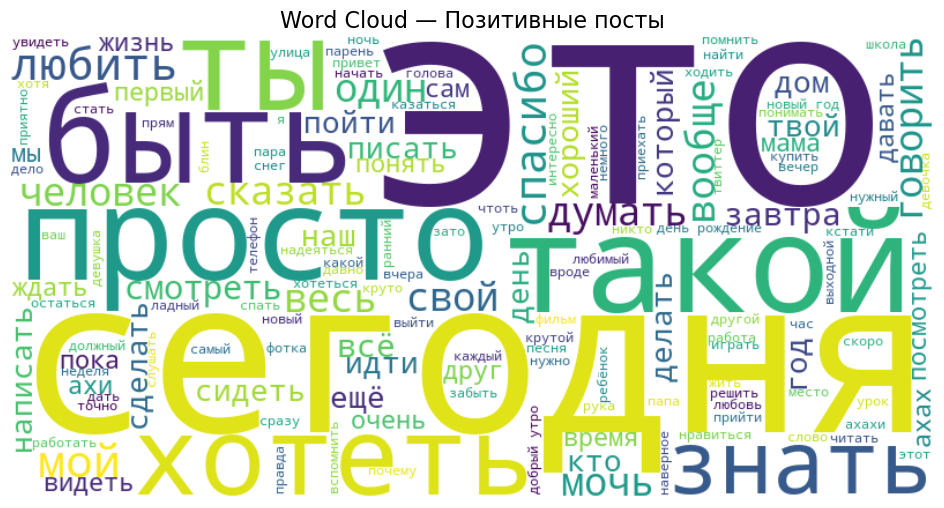

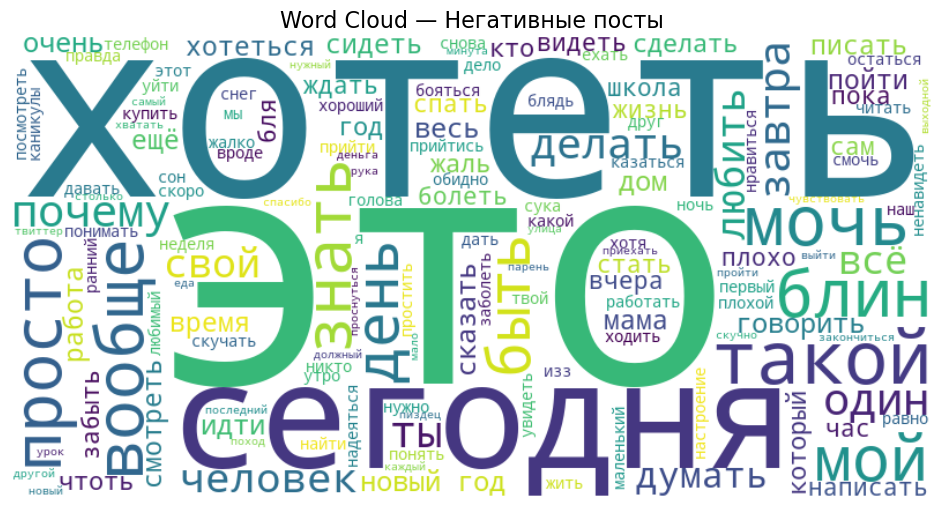

In [12]:
pos_text = ' '.join(dataset[dataset['sentiment'] == 1]['text_clean'])
neg_text = ' '.join(dataset[dataset['sentiment'] == -1]['text_clean'])

# Позитивные посты
plt.figure(figsize=(12, 6))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(pos_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Позитивные посты', fontsize=16)
plt.show()

# Негативные посты
plt.figure(figsize=(12, 6))
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(neg_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Негативные посты', fontsize=16)
plt.show()

## Векторизация

In [13]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(dataset['text_clean'])
print(f"Размер TF-IDF матрицы: {X.shape}")

Размер TF-IDF матрицы: (226200, 5000)


## Тематическое моделирование

In [14]:
def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]]
        print(f"Тема {topic_idx}: {', '.join(top_words)}")

# Общий датасет
nmf = NMF(n_components=6, random_state=42)
nmf.fit(X)

print("=== ТОПИКИ ДЛЯ ВСЕГО ДАТАСЕТА ===")
print_topics(nmf, vectorizer.get_feature_names_out())

# Позитивные посты
X_pos = vectorizer.transform(dataset[dataset['sentiment'] == 1]['text_clean'])
nmf_pos = NMF(n_components=5, random_state=42)
nmf_pos.fit(X_pos)

print("\n=== ТОПИКИ ПОЗИТИВНЫХ ПОСТОВ ===")
print_topics(nmf_pos, vectorizer.get_feature_names_out())

# Негативные посты
X_neg = vectorizer.transform(dataset[dataset['sentiment'] == -1]['text_clean'])
nmf_neg = NMF(n_components=5, random_state=42)
nmf_neg.fit(X_neg)

print("\n=== ТОПИКИ НЕГАТИВНЫХ ПОСТОВ ===")
print_topics(nmf_neg, vectorizer.get_feature_names_out())

=== ТОПИКИ ДЛЯ ВСЕГО ДАТАСЕТА ===
Тема 0: это, просто, знать, думать, это просто, самый, человек, очень, всё, сказать
Тема 1: день, сегодня, быть, весь, завтра, мой, мочь, очень, хороший, просто
Тема 2: хотеть, спать, хотеть спать, блин, идти, посмотреть, никто, спать хотеть, хотеть хотеть, очень хотеть
Тема 3: год, новый, новый год, настроение, скоро, ёлка, подарок, новогодний, скоро новый, снег
Тема 4: такой, знать, человек, почему, просто, вообще, мочь, видеть, говорить, один
Тема 5: ты, любить, спасибо, знать, очень, спасибо ты, скучать, говорить, сказать, человек

=== ТОПИКИ ПОЗИТИВНЫХ ПОСТОВ ===
Тема 0: это, просто, это просто, знать это, самый, круто, сказать, это очень, думать, знать
Тема 1: день, сегодня, рождение, день рождение, хороший, добрый, весь, утро, добрый утро, сегодня день
Тема 2: спасибо, большой, спасибо ты, приятно, спасибо большой, очень, весь, хороший, вечер, спасибо весь
Тема 3: ты, спасибо ты, нужный, привет, удача, новый, твой, нравиться, добро, сон
Тема 4: 